In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
# from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [4]:
# subgraph_llm = ChatOpenAI(model='gpt-4o')
subgraph_llm = ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [6]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [7]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [10]:
# parent_llm = ChatOpenAI(model='gpt-4o-mini')
parent_llm = ChatGroq(model="llama-3.3-70b-versatile")

In [11]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [12]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [13]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

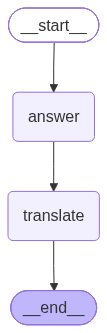

In [14]:
graph = parent_builder.compile()

graph

In [15]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum Physics: A Brief Introduction**\n\nQuantum physics, also known as quantum mechanics, is a branch of physics that studies the behavior of matter and energy at an atomic and subatomic level. It explores the properties and interactions of particles that are too small to be seen with the naked eye, such as atoms, electrons, and photons.\n\n**Key Principles:**\n\n1. **Wave-Particle Duality**: Quantum objects, like electrons, can exhibit both wave-like and particle-like behavior depending on how they are observed.\n2. **Uncertainty Principle**: It is impossible to know certain properties of a quantum object, like its position and momentum, simultaneously with infinite precision.\n3. **Superposition**: Quantum objects can exist in multiple states simultaneously, which is known as a superposition of states.\n4. **Entanglement**: Quantum objects can become "entangled" in a way that their properties are connected, even when separa